# 1. Project Setup

This notebook performs the initial exploratory analysis (Phase 2A) of the fetal movement dataset.

The objectives of this notebook are to:

- Understand the overall dataset structure.
- Inspect recordings and metadata.
- Analyze recording statistics.
- Check data quality.
- Identify missing values.
- Prepare the dataset for the signal processing pipeline.

This notebook does **not** perform preprocessing or machine learning.

In [1]:
# ============================================================
# Project Setup
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib

warnings.filterwarnings("ignore")

# Better plotting
plt.style.use("ggplot")
matplotlib.rcParams["figure.figsize"] = (12, 5)

# ------------------------------------------------------------
# Project Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

DATASET_PATH = PROJECT_ROOT / "data" / "raw" / "fetal" / "four_imu"

print("="*60)
print("Fetal Movement Assessment Project")
print("="*60)

print(f"Project Root : {PROJECT_ROOT}")
print(f"Dataset Path : {DATASET_PATH}")

print("\nDataset Exists :", DATASET_PATH.exists())

Fetal Movement Assessment Project
Project Root : c:\Users\Asus\OneDrive\Desktop\fetal_assesment_project
Dataset Path : c:\Users\Asus\OneDrive\Desktop\fetal_assesment_project\data\raw\fetal\four_imu

Dataset Exists : True


# 2. Dataset Discovery

This section automatically explores the dataset directory and identifies:

- Files
- Subdirectories
- Metadata files
- Recording folders

This provides an overview of the dataset organization before loading any signals.

In [2]:
# ============================================================
# Dataset Discovery
# ============================================================

all_items = sorted(DATASET_PATH.iterdir())

folders = [item for item in all_items if item.is_dir()]
files = [item for item in all_items if item.is_file()]

print(f"Folders : {len(folders)}")
print(f"Files   : {len(files)}")

Folders : 3
Files   : 4


# 3. Dataset Structure

Each recording folder is inspected to understand:

- Number of recording files
- Metadata files
- File types
- Overall organization

In [3]:
# ============================================================
# Dataset Structure
# ============================================================

for folder in folders:

    print("\n" + "="*60)
    print(folder.name)
    print("="*60)

    contents = sorted(folder.iterdir())

    print(f"Total files : {len(contents)}\n")

    for file in contents[:10]:
        print(file.name)

    if len(contents) > 10:
        print("...")


Sub-dataset One
Total files : 25

record_1.csv
record_10.csv
record_11.csv
record_12.csv
record_13.csv
record_14.csv
record_15.csv
record_16.csv
record_17.csv
record_18.csv
...

Sub-dataset Three
Total files : 45

record_1.csv
record_10.csv
record_11.csv
record_12.csv
record_13.csv
record_14.csv
record_15.csv
record_16.csv
record_17.csv
record_18.csv
...

Sub-dataset Two
Total files : 39

record_1.csv
record_10.csv
record_11.csv
record_12.csv
record_13.csv
record_14.csv
record_15.csv
record_16.csv
record_17.csv
record_18.csv
...


In [4]:
# ============================================================
# Select Sub-dataset
# ============================================================

SUB_DATASET = "Sub-dataset One"

recording_files = sorted(
    (DATASET_PATH / SUB_DATASET).glob("record_*.csv")
)

additional_file = DATASET_PATH / f"Additional Data - {SUB_DATASET}.csv"

print("="*60)
print(f"{SUB_DATASET}")
print("="*60)

print(f"Recording Files : {len(recording_files)}")
print(f"Metadata Exists : {additional_file.exists()}")

for file in recording_files[:5]:
    print(file.name)

Sub-dataset One
Recording Files : 25
Metadata Exists : True
record_1.csv
record_10.csv
record_11.csv
record_12.csv
record_13.csv


In [5]:
sample_file = recording_files[0]

print("="*60)
print("Sample Recording")
print("="*60)

print(sample_file.name)

df = pd.read_csv(sample_file)

print(f"\nShape : {df.shape}")

print("\nColumns")

print(df.columns.tolist())

display(df.head())

Sample Recording
record_1.csv

Shape : (64500, 26)

Columns
['time', 'ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1', 'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2', 'ax3', 'ay3', 'az3', 'gx3', 'gy3', 'gz3', 'ax4', 'ay4', 'az4', 'gx4', 'gy4', 'gz4', 'label']


,time,ax1,ay1,az1,gx1,gy1,gz1,ax2,ay2,az2,...,gx3,gy3,gz3,ax4,ay4,az4,gx4,gy4,gz4,label
0,0.000000,15740,3208,4616,-159,13,-15,15092,-7284,2508,...,-974,203,-100,12144,668,-11344,-549,83,-125,0
1,0.033672,15824,3268,4360,-185,-10,-249,15060,-7344,2556,...,-957,176,-103,12104,664,-11308,-542,133,-156,0
2,0.067500,15596,3272,4404,-116,-14,3,15032,-7308,2512,...,-1004,122,-55,11988,524,-11312,-483,90,-151,0
3,0.101268,15740,3204,4688,-138,-52,-255,15012,-7284,2536,...,-997,65,-59,12280,608,-11276,-502,127,-102,0
4,0.134621,15708,3152,4500,-155,255,49,15112,-7332,2752,...,-957,118,-49,12064,612,-11408,-536,249,-130,0


# 4. Recording Statistics

For each recording, we compute:

- Number of samples
- Recording duration
- Number of columns

These statistics provide an overview of the dataset.

In [6]:
# ============================================================
# Recording Statistics
# ============================================================

summary = []

for file in recording_files:

    df = pd.read_csv(file)

    duration = df["time"].iloc[-1] - df["time"].iloc[0]

    movement = (df["label"] == 1).sum()

    total = len(df)

    summary.append({

        "Recording": file.stem,

        "Samples": total,

        "Duration (sec)": round(duration,2),

        "Duration (min)": round(duration/60,2),

        "Movement Samples": movement,

        "Movement %": round(100*movement/total,3)

    })

recording_summary = pd.DataFrame(summary)

display(recording_summary)

,Recording,Samples,Duration (sec),Duration (min),Movement Samples,Movement %
0,record_1,64500,2173.95,36.23,0,0.000
1,record_10,66391,2294.72,38.25,0,0.000
2,record_11,22404,775.55,12.93,4,0.018
3,record_12,52492,1815.28,30.25,11,0.021
4,record_13,42291,1454.63,24.24,0,0.000
5,record_14,64749,2239.05,37.32,0,0.000
6,record_15,52876,1832.00,30.53,0,0.000
7,record_16,28783,995.19,16.59,0,0.000
8,record_17,19299,666.38,11.11,21,0.109
9,record_18,65611,2259.91,37.67,24,0.037


In [7]:
print("="*60)
print("Recording Summary")
print("="*60)

display(recording_summary.describe())

Recording Summary


,Samples,Duration (sec),Duration (min),Movement Samples,Movement %
count,25.000000,25.000000,25.000000,25.000000,25.000000
mean,50037.920000,1720.288400,28.671600,4.320000,0.013520
std,25932.211448,893.835914,14.896962,7.925276,0.027609
min,12612.000000,435.190000,7.250000,0.000000,0.000000
25%,25603.000000,882.570000,14.710000,0.000000,0.000000
50%,53347.000000,1839.840000,30.660000,0.000000,0.000000
75%,65611.000000,2259.910000,37.670000,5.000000,0.009000
max,115639.000000,4001.090000,66.680000,26.000000,0.109000


# 5. Missing Value Analysis

Data quality is assessed by checking:

- Missing values
- Duplicate rows
- Infinite values

A clean dataset reduces preprocessing complexity.

In [8]:
# ============================================================
# Missing Values
# ============================================================

quality = []

for file in recording_files:

    df = pd.read_csv(file)

    quality.append({
        "Recording": file.stem,
        "Missing Values": df.isna().sum().sum(),
        "Duplicate Rows": df.duplicated().sum(),
        "Infinite Values": np.isinf(df.select_dtypes(include=np.number)).sum().sum()
    })

quality_df = pd.DataFrame(quality)

display(quality_df.head())

,Recording,Missing Values,Duplicate Rows,Infinite Values
0,record_1,0,0,0
1,record_10,0,0,0
2,record_11,0,0,0
3,record_12,0,0,0
4,record_13,0,0,0


In [9]:
print("="*60)

print("Dataset Quality Summary")

print("="*60)

print(f"Total Missing Values : {quality_df['Missing Values'].sum()}")

print(f"Total Duplicate Rows : {quality_df['Duplicate Rows'].sum()}")

print(f"Total Infinite Values : {quality_df['Infinite Values'].sum()}")

Dataset Quality Summary
Total Missing Values : 0
Total Duplicate Rows : 0
Total Infinite Values : 0


# 6. Label Analysis

This section analyzes the distribution of fetal movement labels across all recordings.

Objectives:
- Count movement and non-movement samples.
- Measure class imbalance.
- Compute label percentages.
- Analyze label distribution per recording.

In [10]:
# ============================================================
# Locate all recording files
# ============================================================

recording_files = sorted(
    (DATASET_PATH / "Sub-dataset Three").glob("record_*.csv")
)

print(f"Total Recording Files : {len(recording_files)}")

for file in recording_files[:5]:
    print(file.name)

Total Recording Files : 45
record_1.csv
record_10.csv
record_11.csv
record_12.csv
record_13.csv


In [11]:
# ============================================================
# Label Distribution
# ============================================================

label_summary = []

for file in recording_files:

    df = pd.read_csv(file)

    movement = (df["label"] == 1).sum()

    no_movement = (df["label"] == 0).sum()

    total = len(df)

    label_summary.append({

        "Recording": file.stem,

        "Movement": movement,

        "No Movement": no_movement,

        "Total Samples": total,

        "Movement %": round(100*movement/total,3)

    })

label_df = pd.DataFrame(label_summary)

display(label_df)

,Recording,Movement,No Movement,Total Samples,Movement %
0,record_1,59,94585,95043,0.062
1,record_10,105,133407,134145,0.078
2,record_11,111,92812,93917,0.118
3,record_12,8,53939,54528,0.015
4,record_13,0,113681,114040,0.000
5,record_14,11,125646,126259,0.009
6,record_15,8,74321,74781,0.011
7,record_16,7,105309,105802,0.007
8,record_17,146,134975,136421,0.107
9,record_18,16,84664,85059,0.019


In [12]:
total_movement = label_df["Movement"].sum()
total_no_movement = label_df["No Movement"].sum()

print("="*60)
print("Overall Label Distribution")
print("="*60)

print(f"Movement Samples     : {total_movement:,}")
print(f"No Movement Samples  : {total_no_movement:,}")

total = total_movement + total_no_movement

print(f"\nMovement %     : {100*total_movement/total:.2f}%")
print(f"No Movement %  : {100*total_no_movement/total:.2f}%")

Overall Label Distribution
Movement Samples     : 1,902
No Movement Samples  : 4,151,904

Movement %     : 0.05%
No Movement %  : 99.95%


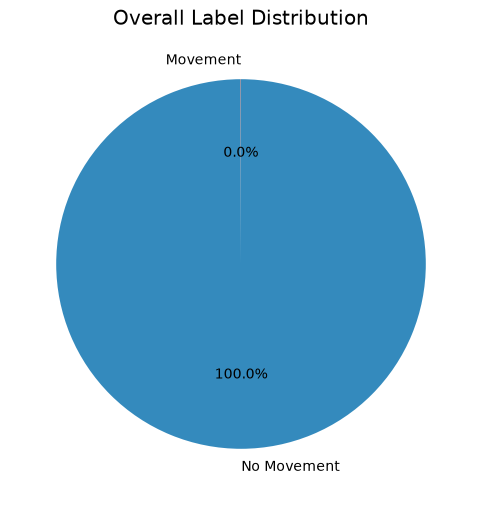

In [13]:
plt.figure(figsize=(6,6))

plt.pie(
    [total_movement, total_no_movement],
    labels=["Movement","No Movement"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Label Distribution")

plt.show()

# 7. Sampling Rate Analysis

The sampling frequency is calculated directly from the timestamps instead of relying on documentation.

In [14]:
# ============================================================
# Sampling Rate Analysis
# ============================================================

sample = pd.read_csv(recording_files[0])

dt = sample["time"].diff().dropna()

sampling_rate = 1 / dt.mean()

duration = sample["time"].iloc[-1] - sample["time"].iloc[0]

sampling_summary = pd.DataFrame({

    "Metric":[

        "Estimated Sampling Rate (Hz)",

        "Average Time Step (s)",

        "Minimum Time Step (s)",

        "Maximum Time Step (s)",

        "Recording Duration (s)"

    ],

    "Value":[

        round(sampling_rate,2),

        dt.mean(),

        dt.min(),

        dt.max(),

        round(duration,2)

    ]

})

display(sampling_summary)

,Metric,Value
0,Estimated Sampling Rate (Hz),29.130000
1,Average Time Step (s),0.034325
2,Minimum Time Step (s),0.032651
3,Maximum Time Step (s),1.235577
4,Recording Duration (s),3262.340000


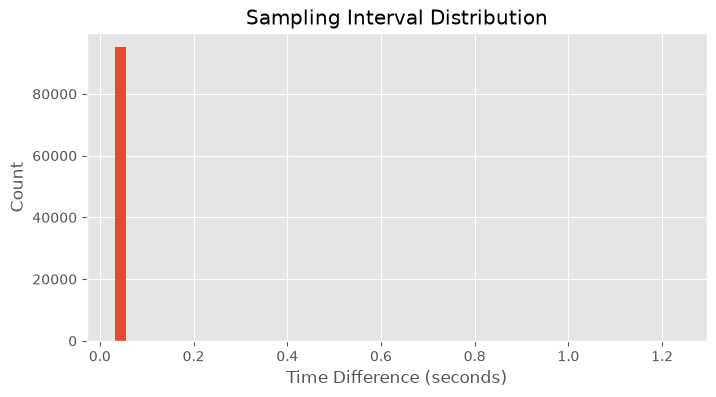

In [15]:
plt.figure(figsize=(8,4))

plt.hist(dt, bins=50)

plt.title("Sampling Interval Distribution")

plt.xlabel("Time Difference (seconds)")
plt.ylabel("Count")

plt.show()

# 8. Signal Visualization

Visualize raw accelerometer signals and overlay fetal movement labels.

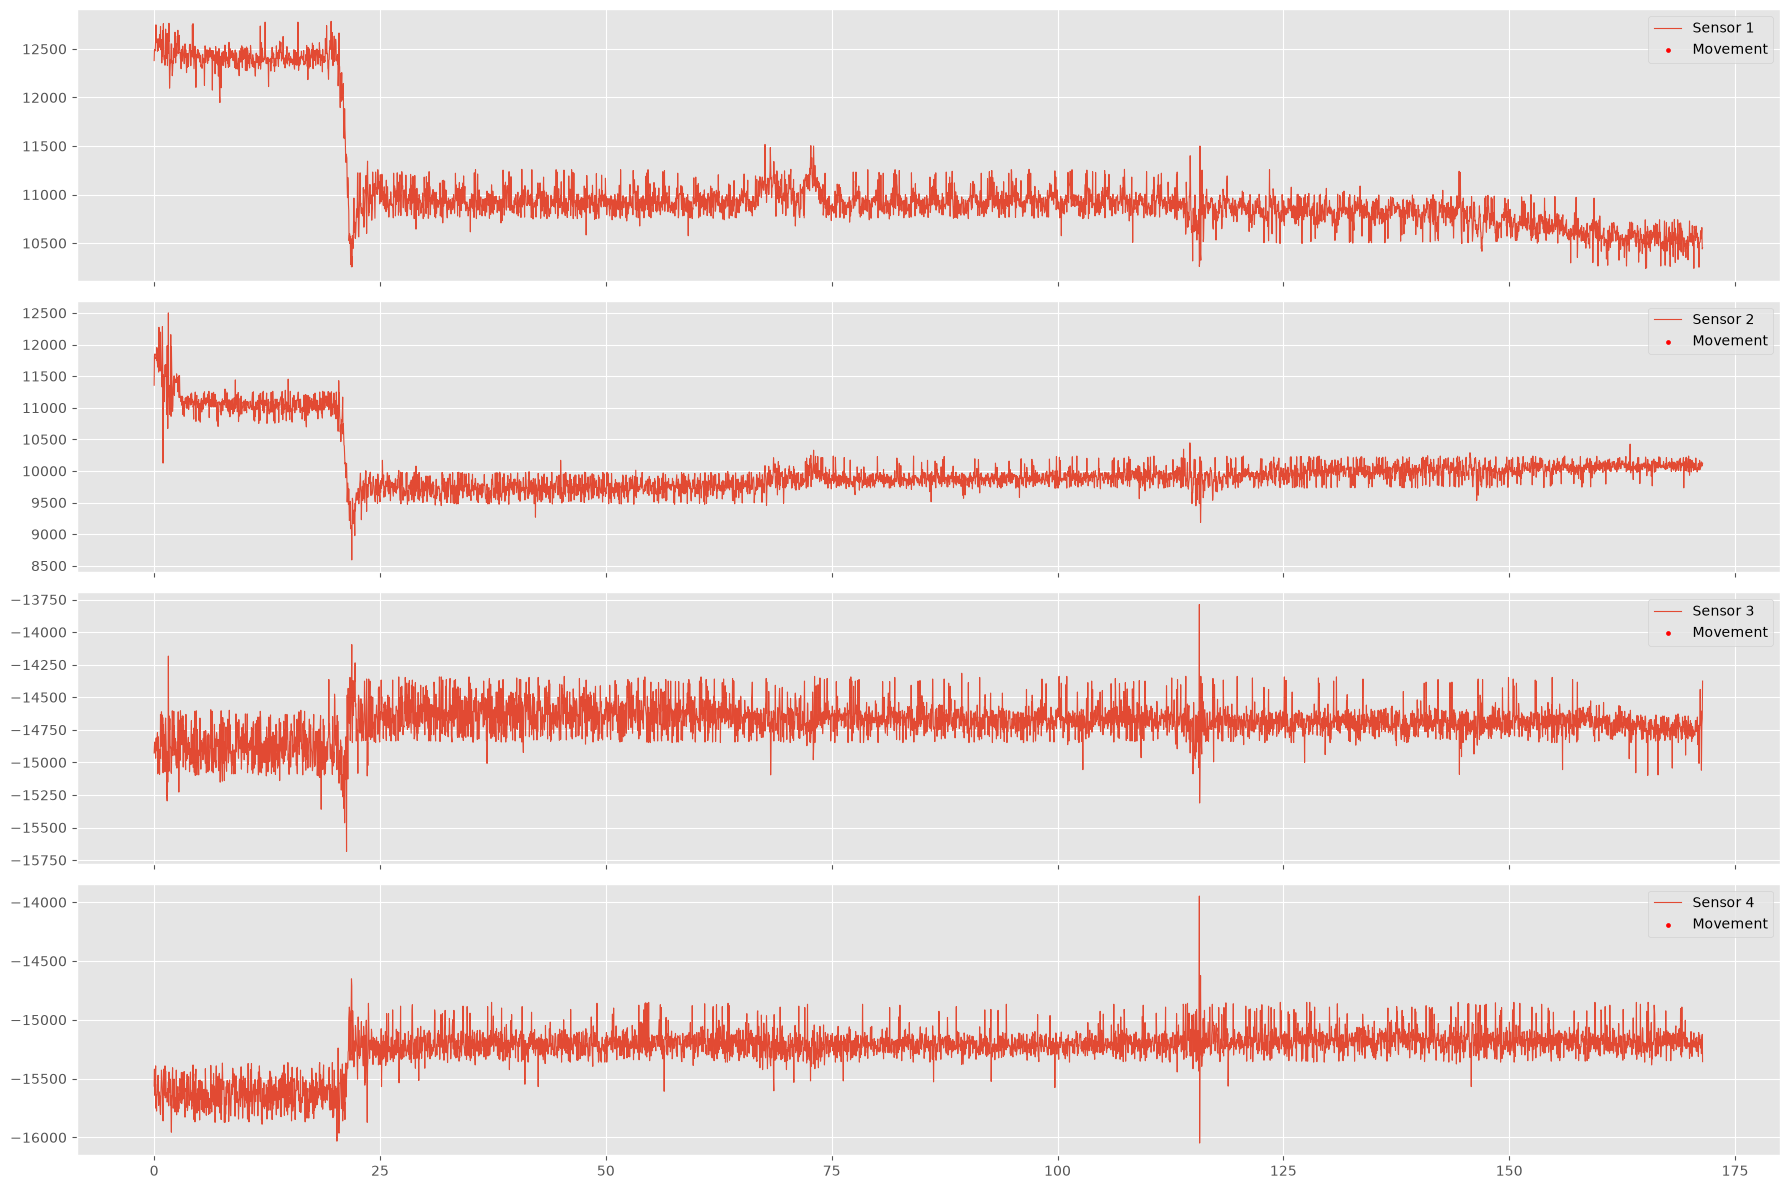

In [16]:
sample = pd.read_csv(recording_files[0])

sample = sample.iloc[:5000]

movement = sample["label"]==1

fig,axes=plt.subplots(4,1,figsize=(18,12),sharex=True)

sensor_list=["1","2","3","4"]

for i,s in enumerate(sensor_list):

    axes[i].plot(sample["time"],sample[f"ax{s}"],linewidth=0.8,label=f"Sensor {s}")

    axes[i].scatter(

        sample.loc[movement,"time"],

        sample.loc[movement,f"ax{s}"],

        s=8,

        c="red",

        label="Movement"

    )

    axes[i].legend()

    axes[i].grid(True)

plt.tight_layout()

plt.show()

# 9. Sensor Correlation Analysis

Correlation analysis identifies redundant sensors and relationships between channels.

In [17]:
# ============================================================
# Sensor Correlation Analysis
# ============================================================

sample = pd.read_csv(recording_files[0])

sensor_columns = sample.columns.drop(["time","label"])

corr = sample[sensor_columns].corr()

display(corr.round(2))

,ax1,ay1,az1,gx1,gy1,gz1,ax2,ay2,az2,gx2,...,az3,gx3,gy3,gz3,ax4,ay4,az4,gx4,gy4,gz4
ax1,1.00,-0.75,-0.96,-0.05,0.01,0.02,0.94,-0.05,-0.92,0.00,...,-0.95,-0.02,-0.00,0.00,-0.91,0.92,-0.82,0.02,-0.01,-0.01
ay1,-0.75,1.00,0.60,0.01,-0.01,-0.02,-0.68,0.57,0.80,0.00,...,0.83,0.03,0.00,-0.01,0.72,-0.88,0.39,-0.00,0.00,0.01
az1,-0.96,0.60,1.00,0.05,-0.00,-0.02,-0.90,-0.11,0.86,0.00,...,0.92,0.01,-0.01,0.00,0.84,-0.85,0.89,-0.03,-0.00,-0.00
gx1,-0.05,0.01,0.05,1.00,0.07,-0.28,-0.06,-0.02,0.05,0.39,...,0.03,-0.32,-0.29,-0.35,0.02,-0.02,0.04,-0.54,0.15,-0.32
gy1,0.01,-0.01,-0.00,0.07,1.00,-0.56,0.02,-0.00,-0.02,0.26,...,-0.01,0.11,-0.77,0.67,0.01,-0.01,0.00,0.00,-0.77,-0.76
gz1,0.02,-0.02,-0.02,-0.28,-0.56,1.00,0.02,-0.02,-0.03,-0.35,...,-0.01,-0.22,0.69,-0.06,-0.00,0.01,-0.00,-0.11,0.29,0.82
ax2,0.94,-0.68,-0.90,-0.06,0.02,0.02,1.00,-0.06,-0.96,0.01,...,-0.86,-0.02,-0.01,0.01,-0.78,0.79,-0.69,0.03,-0.02,-0.02
ay2,-0.05,0.57,-0.11,-0.02,-0.00,-0.02,-0.06,1.00,0.28,-0.01,...,0.19,0.06,0.02,0.00,0.05,-0.26,-0.33,0.01,-0.00,-0.00
az2,-0.92,0.80,0.86,0.05,-0.02,-0.03,-0.96,0.28,1.00,-0.00,...,0.89,0.03,0.00,-0.00,0.76,-0.84,0.62,-0.03,0.01,0.01
gx2,0.00,0.00,0.00,0.39,0.26,-0.35,0.01,-0.01,-0.00,1.00,...,-0.00,-0.37,-0.44,-0.16,-0.01,-0.00,-0.01,-0.20,-0.07,-0.47


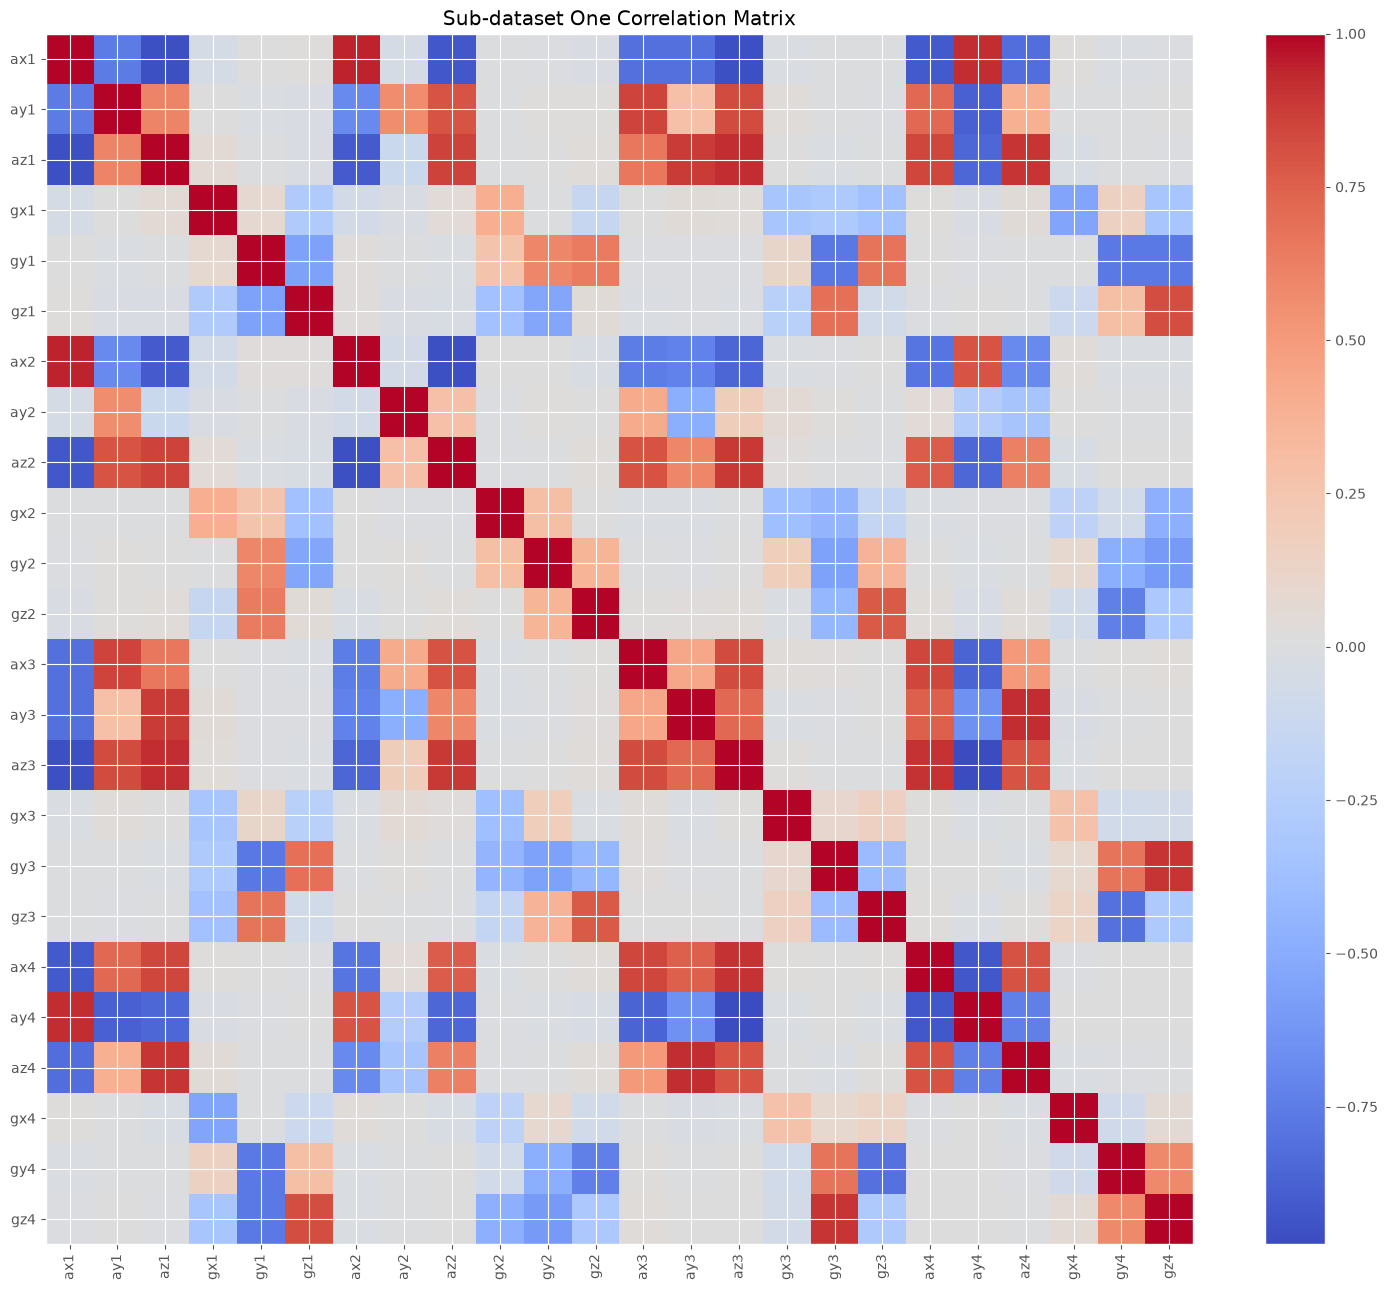

In [18]:
plt.figure(figsize=(15,13))

plt.imshow(corr,cmap="coolwarm",aspect="auto")

plt.colorbar()

plt.xticks(range(len(sensor_columns)),sensor_columns,rotation=90)

plt.yticks(range(len(sensor_columns)),sensor_columns)

plt.title(f"{SUB_DATASET} Correlation Matrix")

plt.tight_layout()

plt.show()

In [19]:
# ============================================================
# Sensor Variance Ranking
# ============================================================

variance = sample[sensor_columns].var().sort_values(ascending=False)

variance_df = variance.reset_index()

variance_df.columns = ["Sensor","Variance"]

display(variance_df)

print("="*60)
print("Top 10 Most Informative Sensor Channels")
print("="*60)

display(variance_df.head(10))

,Sensor,Variance
0,az3,2.951185e+06
1,az2,2.509538e+06
2,ax2,2.156250e+06
3,ax1,2.093078e+06
4,ay4,1.858517e+06
5,az1,1.242926e+06
6,az4,1.149849e+06
7,ay3,6.508137e+05
8,ay1,6.273941e+05
9,ay2,2.775381e+05


Top 10 Most Informative Sensor Channels


,Sensor,Variance
0,az3,2.951185e+06
1,az2,2.509538e+06
2,ax2,2.156250e+06
3,ax1,2.093078e+06
4,ay4,1.858517e+06
5,az1,1.242926e+06
6,az4,1.149849e+06
7,ay3,6.508137e+05
8,ay1,6.273941e+05
9,ay2,2.775381e+05


In [20]:
summary = pd.DataFrame({

"Property":[

"Dataset",

"Sub-dataset",

"Total Recordings",

"Sensors",

"Accelerometer",

"Gyroscope",

"Label Type",

"Sampling Rate"

],

"Value":[

"Four IMU",

SUB_DATASET,

len(recording_files),

4,

"Yes",

"Yes",

"Inline Binary",

f"{sampling_rate:.2f} Hz"

]

})

display(summary)

,Property,Value
0,Dataset,Four IMU
1,Sub-dataset,Sub-dataset One
2,Total Recordings,45
3,Sensors,4
4,Accelerometer,Yes
5,Gyroscope,Yes
6,Label Type,Inline Binary
7,Sampling Rate,29.13 Hz


In [21]:
evaluation = pd.DataFrame({

"Strengths":[

"Four synchronized IMUs",

"Accelerometer + Gyroscope",

"Inline labels",

"Suitable for ML",

"Matches prototype hardware"

],

"Limitations":[

"Mother-perceived labels",

"Class imbalance",

"Limited subjects",

"Different protocols across sub-datasets",

"No explicit artifact labels"

]

})

display(evaluation)

,Strengths,Limitations
0,Four synchronized IMUs,Mother-perceived labels
1,Accelerometer + Gyroscope,Class imbalance
2,Inline labels,Limited subjects
3,Suitable for ML,Different protocols across sub-datasets
4,Matches prototype hardware,No explicit artifact labels


In [22]:
# ============================================================
# Suitability for Research
# ============================================================

evaluation = pd.DataFrame({

"Aspect":[

"Signal Quality",

"Recording Length",

"Sampling Rate",

"Number of IMUs",

"Accelerometer",

"Gyroscope",

"Ground Truth",

"Hardware Similarity",

"Machine Learning",

"Patent Prototype"

],

"Evaluation":[

"Excellent",

"Excellent",

"Excellent",

"4",

"Available",

"Available",

"Inline Labels",

"Very High",

"Highly Suitable",

"Highly Suitable"

]

})

display(evaluation)

,Aspect,Evaluation
0,Signal Quality,Excellent
1,Recording Length,Excellent
2,Sampling Rate,Excellent
3,Number of IMUs,4
4,Accelerometer,Available
5,Gyroscope,Available
6,Ground Truth,Inline Labels
7,Hardware Similarity,Very High
8,Machine Learning,Highly Suitable
9,Patent Prototype,Highly Suitable
